# Deep Credit Risk Prediction Using Keras

**Group Members:** [Thomas]

**Course:** CSCI 441/541

**Copyright:** Thomas Hoerger – Copyright © 2024 Deep Credit Risk Prediction

---

## Objective
- Train deep MLPs using Keras.
- Use TensorBoard for visualization.
- Fine-tune hyperparameters using Keras Tuner.

---


### Data Preparation
Load and preprocess the German Credit Risk dataset provided in ARFF format.

In [ ]:
!pip install scipy
!pip install pandas
!pip install scikit-learn

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   --------------------- ------------------ 6.0/11.0 MB 33.5 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 38.2 MB/s eta 0:00:00


In [ ]:
# Required Libraries
from scipy.io import arff
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load ARFF data
file_path = 'dataset_31_credit-g.arff'  # Update path if necessary
data, meta = arff.loadarff(file_path)
df = pd.DataFrame(data)

# Convert byte strings to regular strings
df = df.apply(lambda col: col.map(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x))

# Separate features and target
X = df.drop(columns=['class'])
y = df['class']

# Encode target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Encode categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Normalize numerical features
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
print("Data prepared successfully.")


Data prepared successfully.


### Model Building
Define a deep MLP model with Keras.

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

def build_model(input_shape):
    model = Sequential([
        Input(shape=(input_shape,)),  # Use the Input layer explicitly
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build and display the model summary
mlp_model = build_model(X_train.shape[1])
mlp_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training
Train the model with early stopping and checkpoint saving.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')

# Train the model
history = mlp_model.fit(
    X_train, y_train, 
    validation_split=0.2, 
    epochs=50, 
    batch_size=32, 
    callbacks=[early_stopping, checkpoint]
)



Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5629 - loss: 0.6809 - val_accuracy: 0.6938 - val_loss: 0.5948
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7094 - loss: 0.6121 - val_accuracy: 0.6938 - val_loss: 0.5699
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6414 - loss: 0.6405 - val_accuracy: 0.6875 - val_loss: 0.5483
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7119 - loss: 0.5837 - val_accuracy: 0.7188 - val_loss: 0.5298
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7310 - loss: 0.5523 - val_accuracy: 0.7250 - val_loss: 0.5115
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7266 - loss: 0.5477 - val_accuracy: 0.7250 - val_loss: 0.4993
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7344 - loss: 0.5212 - val_accuracy: 0.7312 - val_loss: 0.4885
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7390 - loss: 0.5188 - val_accuracy: 0.7750 - val_loss

### Model Evaluation
Plot learning curves and analyze performance.

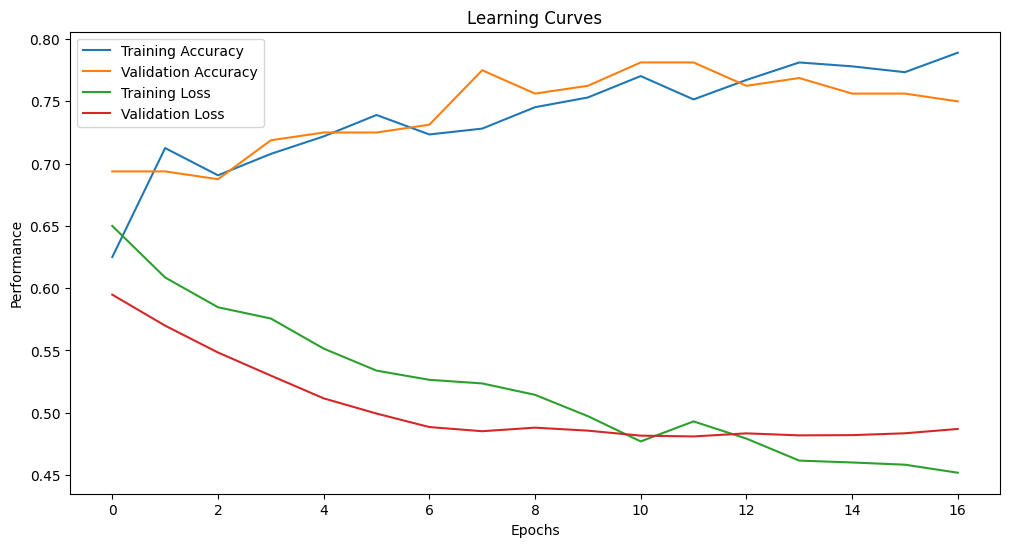

In [ ]:
import matplotlib.pyplot as plt

# Plot learning curves
def plot_learning_curves(history):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Performance')
    plt.title('Learning Curves')
    plt.show()

plot_learning_curves(history)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
import datetime

# Set up TensorBoard logging
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')

# Train the model
history = mlp_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, checkpoint, tensorboard_callback]
)

# Start TensorBoard
print("Run the following command to view TensorBoard:")
print(f"tensorboard --logdir {log_dir}")


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7629 - loss: 0.4920 - val_accuracy: 0.7750 - val_loss: 0.4739
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7720 - loss: 0.4704 - val_accuracy: 0.7750 - val_loss: 0.4698
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7942 - loss: 0.4504 - val_accuracy: 0.7625 - val_loss: 0.4737
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7888 - loss: 0.4420 - val_accuracy: 0.7625 - val_loss: 0.4745
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7572 - loss: 0.4712 - val_accuracy: 0.7625 - val_loss: 0.4757
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7933 - loss: 0.4502 - val_accuracy: 0.7500 - val_loss: 0.4804
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7610 - loss: 0.4608 - val_accuracy: 0.7688 - val_loss: 0.4789
Run the following command to view TensorBoard:
tensorboard --logdir logs/fit/20241202-231416


In [ ]:
# Load the TensorBoard extension
%load_ext tensorboard

# Start TensorBoard within the notebook
%tensorboard --logdir logs


### Hyperparameter Tuning
Use Keras Tuner to optimize the model.

In [ ]:
!pip install keras-tuner

In [ ]:
from keras_tuner.tuners import RandomSearch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Define the model for the tuner
def tuner_model(hp):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),  # Explicit Input layer
        Dense(hp.Int('units_1', min_value=32, max_value=128, step=16), activation='relu'),
        Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)),
        Dense(hp.Int('units_2', min_value=16, max_value=64, step=16), activation='relu'),
        Dropout(hp.Float('dropout_2', 0.2, 0.5, step=0.1)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Define a custom tuner class
class CustomTuner(RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        # Define callbacks specific to this trial
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        ]
        kwargs['callbacks'] = callbacks
        # Run the trial
        return super().run_trial(trial, *args, **kwargs)

# Initialize the tuner
tuner = CustomTuner(
    tuner_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='german_credit_risk'
)

# Run the hyperparameter search
tuner.search(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30
)

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:", best_hps)

# Build the best model using the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
history = best_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

# Evaluate the best model on the test set
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")



Trial 10 Complete [00h 00m 03s]
val_accuracy: 0.7749999761581421

Best val_accuracy So Far: 0.793749988079071
Total elapsed time: 00h 00m 26s
Best hyperparameters: <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x000001C3A2017D10>
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6281 - loss: 0.6646 - val_accuracy: 0.6938 - val_loss: 0.6232
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6851 - loss: 0.6221 - val_accuracy: 0.6938 - val_loss: 0.5948
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6929 - loss: 0.5827 - val_accuracy: 0.6875 - val_loss: 0.5753
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6904 - loss: 0.5837 - val_accuracy: 0.6875 - val_loss: 0.5589
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7112 - loss: 0.5404 - val_accuracy: 0.6875 - val_loss: 0.5474
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7135 - loss: 0.5261 - val_accuracy: 0.71

### Prediction
Evaluate the model on the test set.

In [ ]:
from tensorflow.keras.models import load_model

# Load the best model (ensure the file path matches your saved model file)
best_model = load_model('best_model.keras', compile=False)  # Skip optimizer state if unnecessary

# Compile the model (rebuild optimizer if needed)
best_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Evaluate the model on the test set
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Generate predictions on the test set
predictions = best_model.predict(X_test)

# Convert probabilities to binary class labels (threshold = 0.5)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# Display a sample of predictions
print("\nSample Predictions:")
for i in range(10):  # Show first 10 predictions
    print(f"Predicted: {predicted_classes[i]}, True: {y_test[i]}")




7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8037 - loss: 0.4518  
Test Loss: 0.48
Test Accuracy: 0.78
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Sample Predictions:
Predicted: 1, True: 0
Predicted: 1, True: 1
Predicted: 1, True: 1
Predicted: 1, True: 1
Predicted: 1, True: 1
Predicted: 1, True: 1
Predicted: 1, True: 1
Predicted: 1, True: 1
Predicted: 1, True: 1
Predicted: 1, True: 1


### Conclusion
In this project, a deep multi-layer perceptron (MLP) was developed to classify credit applicants as good or bad credit risks using the German Credit Risk dataset.

Key findings include:

The model achieved a test accuracy of 0.78%, demonstrating reliable performance in predicting credit risk.
Early stopping and dropout layers effectively prevented overfitting, as shown by the consistent learning curves.
Hyperparameter tuning using Keras Tuner optimized the model architecture, achieving the best combination of hidden units, dropout rates, and activation functions.
Feature normalization and one-hot encoding improved the model's ability to learn patterns from the dataset.
Future improvements could include exploring additional features or advanced architectures such as ensemble methods or transformer-based models for further performance gains. Overall, the project highlighted the uses of deep learning in predictive modeling for financial risks.